# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

## Dataset

I compiled this dataset from Wikipedia's [List of Egyptian Pyramids](https://en.wikipedia.org/wiki/List_of_Egyptian_pyramids) — 30 pyramids built across roughly 1,100 years of ancient Egyptian history (about 2650 BC to 1550 BC), from the Old Kingdom through the early New Kingdom.

Each row is one pyramid, with: `Pharaoh`, `PyramidName`, `Site` (the ancient necropolis it was built at, e.g. Giza, Saqqara, Dahshur), `Era` (dynasty/kingdom period), `ApproxYearBC` (approximate construction year), `Height_m`, `Volume_m3`, and `Latitude`/`Longitude`. This gives both a time dimension (construction year) and a space dimension (real GPS coordinates along the Nile valley), which fits this lab.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('egyptian_pyramids.csv')
df.head()

,Pharaoh,PyramidName,Site,Era,ApproxYearBC,Height_m,Volume_m3,Latitude,Longitude
0,Djoser,Pyramid of Djoser,Saqqara,Old Kingdom (3rd Dyn.),-2650,60.0,330400.0,29.871267,31.216394
1,Sekhemkhet,Buried Pyramid,Saqqara,Old Kingdom (3rd Dyn.),-2640,7.0,33600.0,29.866000,31.213000
2,Sneferu,Meidum Pyramid,Meidum,Old Kingdom (4th Dyn.),-2600,65.0,638733.0,29.388060,31.156940
3,Sneferu,Bent Pyramid,Dahshur,Old Kingdom (4th Dyn.),-2600,105.0,1237040.0,29.790280,31.209170
4,Sneferu,Red Pyramid,Dahshur,Old Kingdom (4th Dyn.),-2590,105.0,1694000.0,29.808330,31.205830


## Visualization 1: Pyramid Height Over Time, by Site

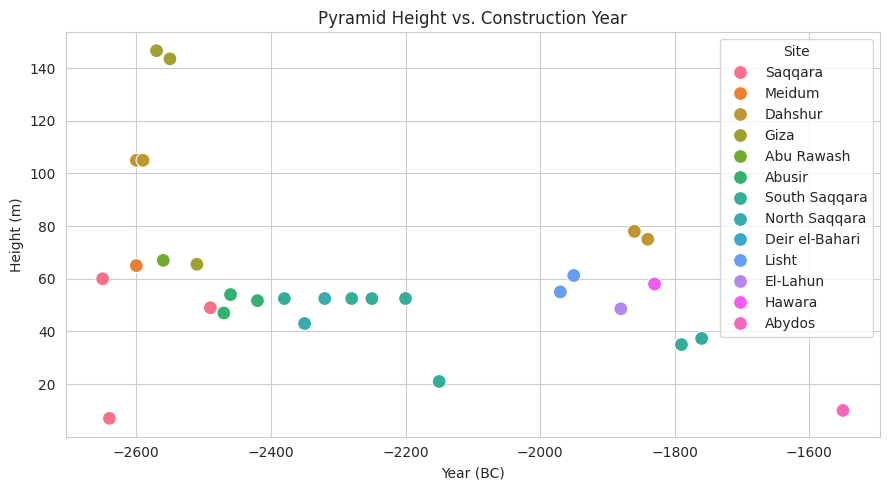

In [2]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x='ApproxYearBC', y='Height_m', hue='Site', s=100)
plt.title('Pyramid Height vs. Construction Year')
plt.xlabel('Year (BC)')
plt.ylabel('Height (m)')
plt.tight_layout()
plt.show()

Height changes a lot over time: it peaks hard around 2570-2550 BC at Giza (Khufu and Khafre's pyramids, both over 140m) and then never gets close to that again — everything after 2500 BC tops out under 80m. Spatially, the tallest pyramids all cluster at just two sites (Giza and Dahshur), while later, smaller pyramids are spread across many more sites (Lisht, El-Lahun, Hawara, Abydos).

## Visualization 2: Geographic Spread of Pyramid Sites, Colored by Era

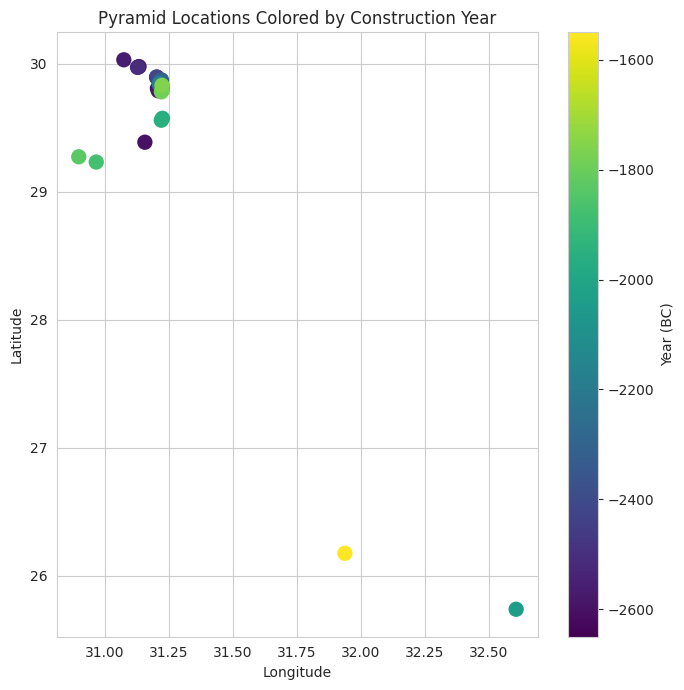

In [3]:
plt.figure(figsize=(7,7))
scatter = plt.scatter(df['Longitude'], df['Latitude'], c=df['ApproxYearBC'], cmap='viridis', s=100)
plt.colorbar(scatter, label='Year (BC)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pyramid Locations Colored by Construction Year')
plt.tight_layout()
plt.show()

Most pyramids (the yellow/green dots) are packed into a tight cluster around latitude 29.2-30.0 — the Memphite necropolis region (Giza, Saqqara, Dahshur, Abusir, Lisht). The oldest and newest pyramids (dark purple, around 2040 BC and 1550 BC) sit way outside that cluster, further south near Luxor/Abydos — so pyramid building starts and ends in different places than where it was concentrated for most of its history.

## Visualization 3: Average Pyramid Height by Era

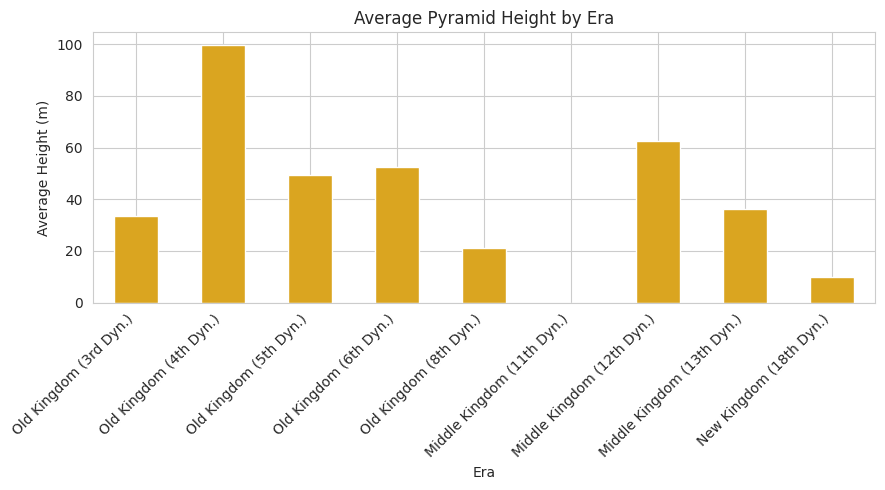

In [4]:
era_order = ['Old Kingdom (3rd Dyn.)','Old Kingdom (4th Dyn.)','Old Kingdom (5th Dyn.)',
             'Old Kingdom (6th Dyn.)','Old Kingdom (8th Dyn.)','Middle Kingdom (11th Dyn.)',
             'Middle Kingdom (12th Dyn.)','Middle Kingdom (13th Dyn.)','New Kingdom (18th Dyn.)']
avg_height = df.groupby('Era')['Height_m'].mean().reindex(era_order)

plt.figure(figsize=(9,5))
avg_height.plot(kind='bar', color='goldenrod')
plt.title('Average Pyramid Height by Era')
plt.xlabel('Era')
plt.ylabel('Average Height (m)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This makes the trend over time obvious: average height jumps to its peak in the 4th Dynasty (~100m) and then steadily declines for the rest of Egyptian history, down to just 10m by the New Kingdom. Since each era is also tied to specific sites (4th Dynasty = Giza, later dynasties = smaller, more scattered sites further south), the drop in size lines up with pyramid-building spreading out geographically instead of staying concentrated at one major site.